## Setup

In [1]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import normaltest, ttest_rel
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display

In [3]:
# Configure plot settings

from re import X
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, LogFormatter
from matplotlib import rc
import matplotlib.gridspec as gridspec
import warnings


warnings.filterwarnings("ignore")

factuality_cmap = {
    True: "#7EACB5",
    False: "#BF4646",
}

conversion_cmap = {
    "P to A": "#B7BDF7",
    "A to P": "#576A8F",
    "Both": "#FFF8DE"
}

metrics = [
    'surp_mean', # Mean surprisal
    'surp_slor', # SLOR
    'uid_std', # Std. of surprisal
    'uid_mad', # mean avg. deviation of surprisal
    'uid_pwd', # Local variance (pairwise euc. distance)
    'uid_range', # Range of surprisal
    'uid_slope', # Slope of a linear function fit to surp values
]

metrics_formatted = [
    'Surp. Mean',
    'SLOR',
    'Surp. STD',
    'Surp. MAD',
    'Local Var.',
    'Surp. Range',
    'LinReg Slope',
]

metrics_mapping = dict(zip(metrics, metrics_formatted))
# metrics_cmap = dict(zip([
#     'surp_slor', ''
# ]))

sns.set_palette("Set2")
# sns.set(rc={
#     'axes.facecolor':'#e5d9b6', 
#     'figure.facecolor':'#e5d9b6'
# })
# Font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times",
})

In [ ]:
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

## Sentence-level

In [ ]:
data_path = "../outputs/cf_word_sentence_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]

In [5]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvl = 'document'
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [7]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)

In [8]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [9]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(39040, 19)

In [12]:
cf_comparison = sents_of_interest[sents_of_interest['context']==context_lvl].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] > 1)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
cf_comparison.head()

,doc_name,sent_idx,level_2,doc_id,context,sentence,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,passive
0,GUM_academic_art,8,0,cf::GUM_academic_art::8::a>p,document,Do museum labels have an impact on how people ...,5.596717,4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,False,8,A to P,True
1,GUM_academic_art,8,1,f::GUM_academic_art::-1::og,document,Do museum labels have an impact on how people ...,5.596717,4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,True,-1,A to P,False
2,GUM_academic_art,11,2,cf::GUM_academic_art::11::a>p,document,A collaborative pilot project focusing on a un...,8.397016,2.723669,8.769274,5.802251,204.251054,39.907106,1.044332,-0.015118,19,False,11,A to P,True
3,GUM_academic_art,11,3,f::GUM_academic_art::-1::og,document,This paper describes a collaborative pilot pro...,8.279072,3.236220,8.889991,5.762708,200.754222,39.123034,1.073791,0.464200,17,True,-1,A to P,False
4,GUM_academic_art,16,4,cf::GUM_academic_art::16::a>p,document,The potential implications of these techniques...,6.231897,4.202044,3.934182,3.250515,24.923332,15.087298,0.631298,0.002615,22,False,16,A to P,True


In [13]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

### Counterfactual vs. Factual

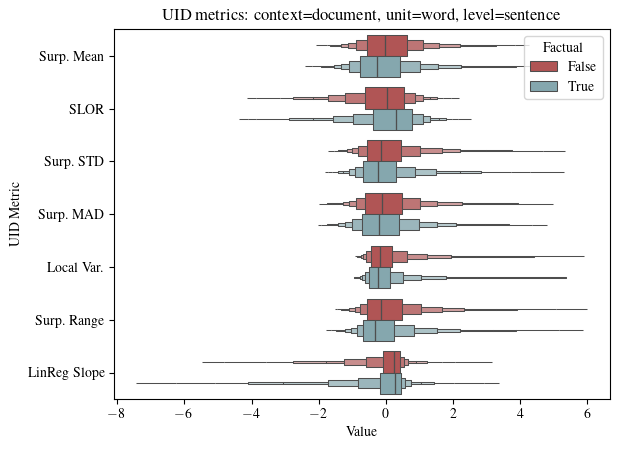

In [15]:
fig, ax = plt.subplots()
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=metrics,
       var_name='UID Metric',
       value_name='Value'
       ),
        hue='factual', x='Value', y='UID Metric', ax=ax, palette=factuality_cmap,
        showfliers=False)
plt.title(f"UID metrics: context={context_lvl}, unit={uid_unit}, level={uid_level}")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")
ax.set_yticks(ticks=metrics, labels=metrics_formatted)
fig.savefig("../plots/uid_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [16]:
get_diff = lambda s: s.diff().iloc[1]
agg_map = dict(zip(metrics, [get_diff] * len(metrics)))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A'
})
pw_diffs = (cf_comparison
            .sort_values(by='factual') # Always Factual - Counterfactual
            .groupby(['doc_name','sent_idx'])
            [metrics + ['conversion']]
            .aggregate(
                agg_map
                )
            .reset_index())
pw_diffs

,doc_name,sent_idx,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_slope,conversion
0,GUM_academic_art,8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A to P
1,GUM_academic_art,11,-0.060938,0.257940,0.071232,-0.031761,-0.057022,-0.101221,0.538265,A to P
2,GUM_academic_art,16,-0.096035,0.017619,0.106847,-0.061610,0.030320,0.004548,0.191935,A to P
3,GUM_academic_art,17,-0.125248,0.313225,-0.330585,-0.212285,-0.004976,-0.776601,0.044467,A to P
4,GUM_academic_art,20,-0.272233,0.185716,-0.228783,-0.179756,-0.112281,-0.227514,0.042358,P to A
...,...,...,...,...,...,...,...,...,...,...
2434,GUM_whow_skittles,50,-0.958085,1.139512,0.421567,0.760529,0.151464,-0.049825,0.082159,A to P
2435,GUM_whow_skittles,51,-0.000622,0.000606,-0.000163,-0.000157,0.000029,-0.002050,0.000336,A to P
2436,GUM_whow_skittles,52,-0.191273,0.241414,0.068540,0.093599,0.146643,-0.156336,0.037651,A to P
2437,GUM_whow_skittles,53,-0.295958,0.367564,-0.169431,-0.003109,0.062476,-0.917087,0.070204,A to P


In [17]:
pw_diffs['conversion'].value_counts(normalize=True)

conversion
A to P    0.943009
P to A    0.056991
Name: proportion, dtype: float64

In [18]:
pw_diffs_resampled = pd.concat([
    pw_diffs[pw_diffs['conversion'] == 'A to P'].sample((pw_diffs['conversion'] == 'P to A').sum(), replace=False),
    pw_diffs[pw_diffs['conversion'] == 'P to A']
])
pw_diffs_resampled['conversion'].value_counts(normalize=True)

conversion
A to P    0.5
P to A    0.5
Name: proportion, dtype: float64

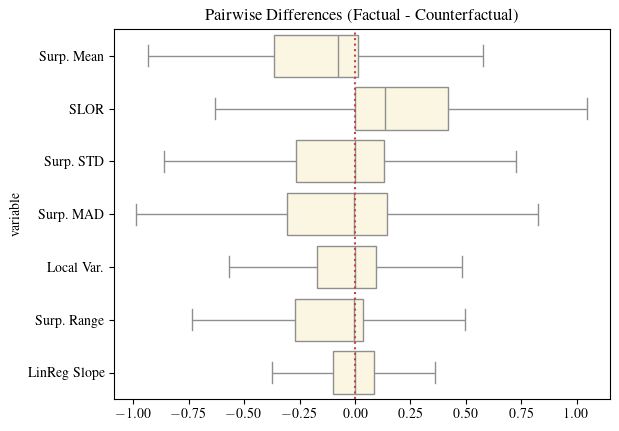

In [19]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion'])), 
            x='value', y='variable', 
            color=conversion_cmap['Both'],
            showfliers=False,
            # inner=None
            )
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title("Pairwise Differences (Factual - Counterfactual)")
plt.xlabel('')
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_fact-counterfact" + plot_suffix,
            dpi=100, bbox_inches='tight')

In [20]:
def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

In [21]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [22]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   P-value |   Observed abs. diff |
|:-------------|----------:|---------------------:|
| Surp. Mean   |      0    |                 0.17 |
| SLOR         |      0    |                 0.22 |
| Surp. STD    |      0    |                 0.11 |
| Surp. MAD    |      0    |                 0.09 |
| Local Var.   |      0.02 |                 0.06 |
| Surp. Range  |      0    |                 0.17 |
| LinReg Slope |      0    |                 0.09 |

In [23]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_comparison.loc[cf_comparison['factual']]
    cfactuals = cf_comparison.loc[~cf_comparison['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="less"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [24]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:-------------|---------------:|------------------:|--------------:|-----------------:|
| Surp. Mean   |         381.67 |                 0 |        -16.27 |                0 |
| SLOR         |         382.49 |                 0 |         22.3  |                1 |
| Surp. STD    |         710.94 |                 0 |         -8.32 |                0 |
| Surp. MAD    |         433    |                 0 |         -6.27 |                0 |
| Local Var.   |         835.1  |                 0 |         -6.15 |                0 |
| Surp. Range  |         805.81 |                 0 |        -13.81 |                0 |
| LinReg Slope |        1312.9  |                 0 |         -4.76 |                0 |

In [25]:
factual_passives_sample = cf_comparison[cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
factual_actives_sample = cf_comparison[~cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
pass_vs_act = pd.concat([factual_passives_sample, factual_actives_sample])

In [26]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(pass_vs_act, 'passive', metric, 10000,
                            test_stat=lambda a, b: b-a,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False


In [27]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric    |   observed |   pval |
|---:|:----------|-----------:|-------:|
|  0 | surp_mean |  0.410023  | 0      |
|  1 | surp_slor | -0.563715  | 1      |
|  2 | uid_std   |  0.0248277 | 0.1725 |
|  3 | uid_mad   |  0.13839   | 0      |
|  4 | uid_pwd   | -0.0091105 | 0.6584 |
|  5 | uid_range | -0.283855  | 1      |
|  6 | uid_slope | -0.416733  | 1      |


### Passive vs. Active

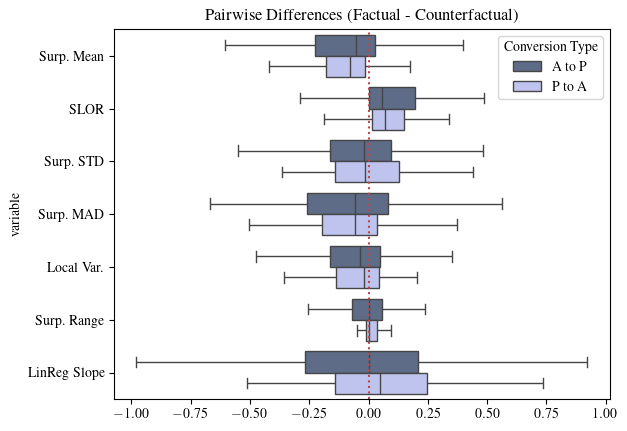

In [204]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion'])), 
            x='value', y='variable', 
            palette=conversion_cmap, hue='conversion',
            showfliers=False,
            # inner=None
            )
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title("Pairwise Differences (Factual - Counterfactual)")
plt.xlabel('')
plt.legend(title="Conversion Type", bbox_to_anchor=(1.0, 1.0))
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

In [29]:
results = []
for metric in metrics:
    p_to_a = cf_comparison[cf_comparison['conversion']=='P to A'].sort_values('factual')
    a_to_p = cf_comparison[cf_comparison['conversion']=='A to P'].sort_values('factual')
    for data in [p_to_a, a_to_p]:
        obs, sim, p_val = perm_test(data, 
                                'factual', 
                                metric, 
                                10000,
                                )
        results.append({
            "Metric": metrics_mapping[metric],
            "Conversion Type": data['conversion'].unique()[0],
            "P-value": p_val,
            "Observed abs. diff": obs,
            "Simulated abs. diff": sim
        })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [30]:
output_name = "../plots/diff_means_perm_pass-v-act" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       | Conversion Type   |   P-value |   Observed abs. diff |
|:-------------|:------------------|----------:|---------------------:|
| Surp. Mean   | P to A            |      0    |                 0.61 |
| Surp. Mean   | A to P            |      0    |                 0.14 |
| SLOR         | P to A            |      0    |                 0.41 |
| SLOR         | A to P            |      0    |                 0.21 |
| Surp. STD    | P to A            |      0    |                 0.4  |
| Surp. STD    | A to P            |      0    |                 0.09 |
| Surp. MAD    | P to A            |      0    |                 0.43 |
| Surp. MAD    | A to P            |      0.03 |                 0.07 |
| Local Var.   | P to A            |      0.08 |                 0.15 |
| Local Var.   | A to P            |      0.05 |                 0.06 |
| Surp. Range  | P to A            |      0.02 |                 0.31 |
| Surp. Range  | A to P            |      0    |                 0.16 |
| LinReg Slope | P to A            |      0.03 |                 0.17 |
| LinReg Slope | A to P            |      0    |                 0.11 |

In [31]:
results = []
for metric in metrics:
    for conv in ['P to A', 'A to P']:
        metric_diffs = pw_diffs.loc[pw_diffs['conversion']==conv, metric]
        normal_res = normaltest(metric_diffs)
        factuals = cf_comparison.loc[cf_comparison['factual'] 
                                     & (cf_comparison['conversion']==conv)]
        cfactuals = cf_comparison.loc[~cf_comparison['factual']
                                      & (cf_comparison['conversion']==conv)]
        ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                            alternative="less"
                            )
        results.append({
            'Metric': metrics_mapping[metric],
            'Conversion Type': conv,
            'Normality TS': normal_res.statistic,
            'Normality P-val': normal_res.pvalue,
            'Paired-t TS': ttest_res.statistic,
            'Paired-t P-val': ttest_res.pvalue
        })
results = pd.DataFrame(results)

In [32]:
output_name = "../plots/norm_pairedt_pass-v-act" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       | Conversion Type   |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:-------------|:------------------|---------------:|------------------:|--------------:|-----------------:|
| Surp. Mean   | P to A            |          45.18 |                 0 |        -13.5  |             0    |
| Surp. Mean   | A to P            |         379.54 |                 0 |        -13.66 |             0    |
| SLOR         | P to A            |          24.65 |                 0 |         11.19 |             1    |
| SLOR         | A to P            |         369.3  |                 0 |         20.49 |             1    |
| Surp. STD    | P to A            |          38.33 |                 0 |         -7.06 |             0    |
| Surp. STD    | A to P            |         692.85 |                 0 |         -6.84 |             0    |
| Surp. MAD    | P to A            |          20.22 |                 0 |         -8.1  |             0    |
| Surp. MAD    | A to P            |         426.03 |                 0 |         -4.65 |             0    |
| Local Var.   | P to A            |          68.63 |                 0 |         -3.96 |             0    |
| Local Var.   | A to P            |         784.87 |                 0 |         -5.44 |             0    |
| Surp. Range  | P to A            |          64.66 |                 0 |         -4.98 |             0    |
| Surp. Range  | A to P            |         734.12 |                 0 |        -12.93 |             0    |
| LinReg Slope | P to A            |         128.32 |                 0 |          2.14 |             0.98 |
| LinReg Slope | A to P            |        1369.39 |                 0 |         -5.44 |             0    |

## Document-level

In [175]:
def extract_sents_of_interest_document_lvl(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if (sent['conv_idx'] in [sent['sent_idx'], -1]):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def repeat_factuals(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']]
    counterfactual_values = group[~group['factual']]
    num_cf = counterfactual_values.shape[0]
    repeated = [factual_values] * num_cf
    out = pd.concat(repeated + [counterfactual_values]).reset_index(drop=True)
    return out

def process_diffs(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']].iloc[0]
    counterfactual_values = group[~group['factual']]
    counterfactual_values[metrics] = - counterfactual_values[metrics] + factual_values[metrics]
    return counterfactual_values

In [176]:
data_path = "../outputs/cf_word_document_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]
uid_df.shape

(12529, 13)

In [177]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvl = 'document' # has to be document for doc-level analysis
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [178]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['sent_idx'] = uid_df['sent_idx'].astype(int)
uid_df.shape

(12529, 17)

In [179]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [180]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest_document_lvl).reset_index().drop(columns="level_1")
sents_of_interest.shape

(12529, 17)

In [181]:
cf_comparison = sents_of_interest[sents_of_interest['context']==context_lvl]#.drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby('doc_name').filter(lambda g: g.shape[0] > 1)
map_conversion = lambda conv: 'A to P' if conv == 'a>p' else 'P to A' if conv == 'p>a' else conv
cf_comparison['conversion'] = cf_comparison['conversion'].apply(map_conversion)
cf_comparison.shape
# cf_comparison.sort_values(['doc_name', 'sent_idx']).head()

(1474, 17)

In [182]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

In [183]:
for name in cf_comparison['doc_name'].unique():
    try:
        group = cf_comparison[cf_comparison['doc_name'] == name]
        factual_values = group[group['factual']].iloc[0]
        counterfactual_values = group[~group['factual']]
        counterfactual_values[metrics] = factual_values[metrics] - counterfactual_values[metrics]
    except Exception as e:
        print(e)
        print(name)

single positional indexer is out-of-bounds
GUM_fiction_veronique
single positional indexer is out-of-bounds
GUM_textbook_anthropology


In [194]:
pw_diffs = (cf_comparison
            .groupby(['doc_name'])
            .apply(process_diffs)
            .reset_index())
for metric in metrics:
    pw_diffs[metric] = pw_diffs[metric].astype(float)
pw_diffs.head()

,doc_name,level_1,doc_id,sent_idx,context,sentence,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion
0,GUM_academic_art,1,cf::GUM_academic_art::8::a>p,8,document,Do museum labels have an impact on how people ...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.009614,0.000000,653,False,8,A to P
1,GUM_academic_art,2,cf::GUM_academic_art::11::a>p,11,document,A collaborative pilot project focusing on a un...,-0.002963,0.011331,0.001617,-0.005603,-0.024565,1.561552e-06,1.009082,0.029441,655,False,11,A to P
2,GUM_academic_art,3,cf::GUM_academic_art::16::a>p,16,document,The potential implications of these techniques...,-0.012911,0.005173,0.008065,-0.001432,0.005389,-1.768092e-06,1.007150,-0.025690,655,False,16,A to P
3,GUM_academic_art,4,cf::GUM_academic_art::17::a>p,17,document,Established research strengths in Spanish art ...,-0.019707,0.039481,0.007884,-0.000240,0.023924,9.808131e-07,1.006505,-0.014333,655,False,17,A to P
4,GUM_academic_art,5,cf::GUM_academic_art::20::p>a,20,document,An interaction between the goals of the observ...,-0.030530,0.011808,0.004550,0.016652,0.001552,7.098010e-07,1.005928,0.027965,651,False,20,P to A


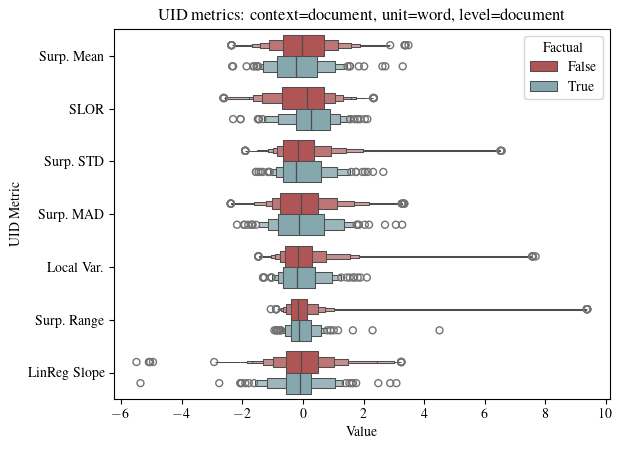

In [195]:
fig, ax = plt.subplots()
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=metrics,
       var_name='UID Metric',
       value_name='Value'
       ),
        hue='factual', x='Value', y='UID Metric', ax=ax, palette=factuality_cmap,
        showfliers=True)
plt.title(f"UID metrics: context={context_lvl}, unit={uid_unit}, level={uid_level}")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")
ax.set_yticks(ticks=metrics, labels=metrics_formatted)
fig.savefig("../plots/uid_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

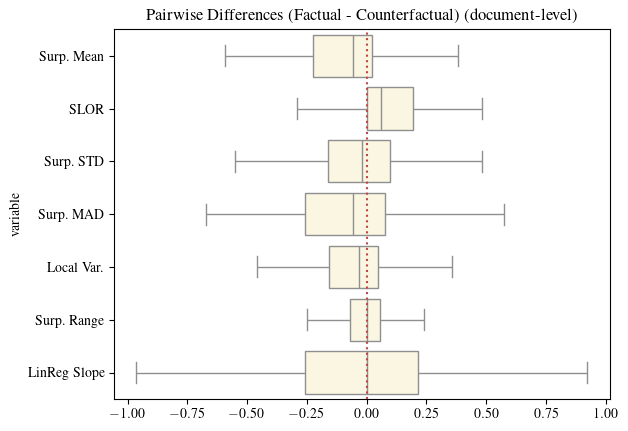

In [196]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion'])), 
            x='value', y='variable', 
            color=conversion_cmap['Both'],
            showfliers=False,
            # inner=None
            )
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title(f"Pairwise Differences (Factual - Counterfactual) ({uid_level}-level)")
plt.xlabel('')
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_fact-counterfact" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [197]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [198]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   P-value |   Observed abs. diff |
|:-------------|----------:|---------------------:|
| Surp. Mean   |      0.17 |                 0.13 |
| SLOR         |      0    |                 0.27 |
| Surp. STD    |      0.92 |                 0.01 |
| Surp. MAD    |      0.95 |                 0.01 |
| Local Var.   |      0.49 |                 0.07 |
| Surp. Range  |      0.99 |                 0    |
| LinReg Slope |      0.15 |                 0.14 |

In [199]:
cf_repeated = (cf_comparison
               .groupby("doc_name")
               .apply(repeat_factuals)
               .reset_index()
               .sort_values('doc_name'))

In [200]:
pw_diffs.dtypes

doc_name          str
level_1         int64
doc_id            str
sent_idx        int64
context           str
sentence          str
surp_mean     float64
surp_slor     float64
uid_std       float64
uid_mad       float64
uid_pwd       float64
uid_range     float64
uid_cv        float64
uid_slope     float64
uid_len         int64
factual          bool
conv_idx        int64
conversion        str
dtype: object

In [201]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_repeated.loc[cf_repeated['factual']]
    cfactuals = cf_repeated.loc[~cf_repeated['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="less"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [202]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:-------------|---------------:|------------------:|--------------:|-----------------:|
| Surp. Mean   |          61.98 |                 0 |         -9.14 |             0    |
| SLOR         |          25.24 |                 0 |         17.62 |             1    |
| Surp. STD    |        1317.2  |                 0 |         -2.43 |             0.01 |
| Surp. MAD    |         111.38 |                 0 |         -5.55 |             0    |
| Local Var.   |        1740.98 |                 0 |         -5.57 |             0    |
| Surp. Range  |        1472.94 |                 0 |         -0.43 |             0.33 |
| LinReg Slope |         124.02 |                 0 |         -3.07 |             0    |